<a href="https://www.kaggle.com/code/sonawanelalitsunil/health-lifestyle-dataset-ml-75-17?scriptVersionId=263544186" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/health-and-lifestyle-dataset/health_lifestyle_dataset.csv


## Title:
📊 Health & Lifestyle Dataset

## Description:
This dataset captures key health and lifestyle factors influencing individual well-being. It includes demographic details, medical conditions, lifestyle habits, genetic history, and treatment information. With features such as age, BMI, chronic diseases, tumor markers, symptom severity, smoking status, alcohol consumption, family history, and survival years after diagnosis, the dataset provides a comprehensive foundation for analyzing health outcomes, identifying risk factors, and building predictive healthcare models.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/health-and-lifestyle-dataset/health_lifestyle_dataset.csv")

In [3]:
df.head()

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


In [4]:
df.tail()

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
99995,99996,53,Male,33.1,4726,3.9,2.0,3118,0,1,56,105,76,282,0,0
99996,99997,22,Male,35.1,11554,4.5,3.1,1967,0,0,51,149,77,192,0,0
99997,99998,37,Male,18.9,3924,3.8,1.0,2328,0,0,69,92,117,218,0,0
99998,99999,72,Female,27.8,16110,5.6,0.8,3093,0,0,93,164,72,188,0,0
99999,100000,37,Male,35.4,8222,9.1,1.8,3942,0,1,71,145,80,276,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 100000 non-null  int64  
 1   age                100000 non-null  int64  
 2   gender             100000 non-null  object 
 3   bmi                100000 non-null  float64
 4   daily_steps        100000 non-null  int64  
 5   sleep_hours        100000 non-null  float64
 6   water_intake_l     100000 non-null  float64
 7   calories_consumed  100000 non-null  int64  
 8   smoker             100000 non-null  int64  
 9   alcohol            100000 non-null  int64  
 10  resting_hr         100000 non-null  int64  
 11  systolic_bp        100000 non-null  int64  
 12  diastolic_bp       100000 non-null  int64  
 13  cholesterol        100000 non-null  int64  
 14  family_history     100000 non-null  int64  
 15  disease_risk       100000 non-null  int64  
dtypes: 

In [6]:
df.describe()

,id,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,48.525990,29.024790,10479.87029,6.491784,2.751496,2603.341200,0.200940,0.300020,74.457420,134.58063,89.508850,224.300630,0.299150,0.248210
std,28867.657797,17.886768,6.352666,5483.63236,2.021922,1.297338,807.288563,0.400705,0.458269,14.423715,25.95153,17.347041,43.327749,0.457888,0.431976
min,1.000000,18.000000,18.000000,1000.00000,3.000000,0.500000,1200.000000,0.000000,0.000000,50.000000,90.00000,60.000000,150.000000,0.000000,0.000000
25%,25000.750000,33.000000,23.500000,5729.00000,4.700000,1.600000,1906.000000,0.000000,0.000000,62.000000,112.00000,74.000000,187.000000,0.000000,0.000000
50%,50000.500000,48.000000,29.000000,10468.00000,6.500000,2.800000,2603.000000,0.000000,0.000000,74.000000,135.00000,89.000000,224.000000,0.000000,0.000000
75%,75000.250000,64.000000,34.500000,15229.00000,8.200000,3.900000,3299.000000,0.000000,1.000000,87.000000,157.00000,105.000000,262.000000,1.000000,0.000000
max,100000.000000,79.000000,40.000000,19999.00000,10.000000,5.000000,3999.000000,1.000000,1.000000,99.000000,179.00000,119.000000,299.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

id                   0
age                  0
gender               0
bmi                  0
daily_steps          0
sleep_hours          0
water_intake_l       0
calories_consumed    0
smoker               0
alcohol              0
resting_hr           0
systolic_bp          0
diastolic_bp         0
cholesterol          0
family_history       0
disease_risk         0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

id                     int64
age                    int64
gender                object
bmi                  float64
daily_steps            int64
sleep_hours          float64
water_intake_l       float64
calories_consumed      int64
smoker                 int64
alcohol                int64
resting_hr             int64
systolic_bp            int64
diastolic_bp           int64
cholesterol            int64
family_history         int64
disease_risk           int64
dtype: object

In [10]:
df.shape

(100000, 16)

In [11]:
df.columns

Index(['id', 'age', 'gender', 'bmi', 'daily_steps', 'sleep_hours',
       'water_intake_l', 'calories_consumed', 'smoker', 'alcohol',
       'resting_hr', 'systolic_bp', 'diastolic_bp', 'cholesterol',
       'family_history', 'disease_risk'],
      dtype='object')

## Data visualizations

Text(0.5, 1.0, 'Age Distribution')

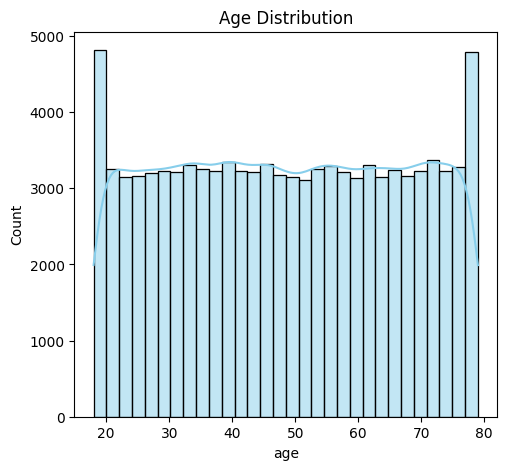

In [12]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['age'], bins=30, kde=True, color="skyblue")
plt.title("Age Distribution")


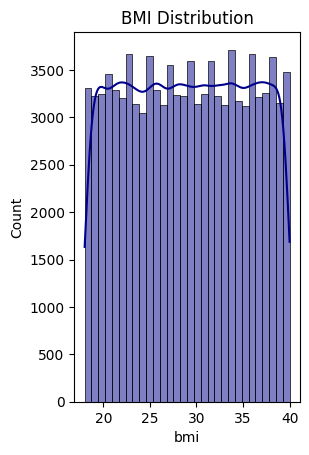

In [13]:
plt.subplot(1,2,2)
sns.histplot(df['bmi'], bins=30, kde=True, color="darkblue")
plt.title("BMI Distribution")
plt.show()

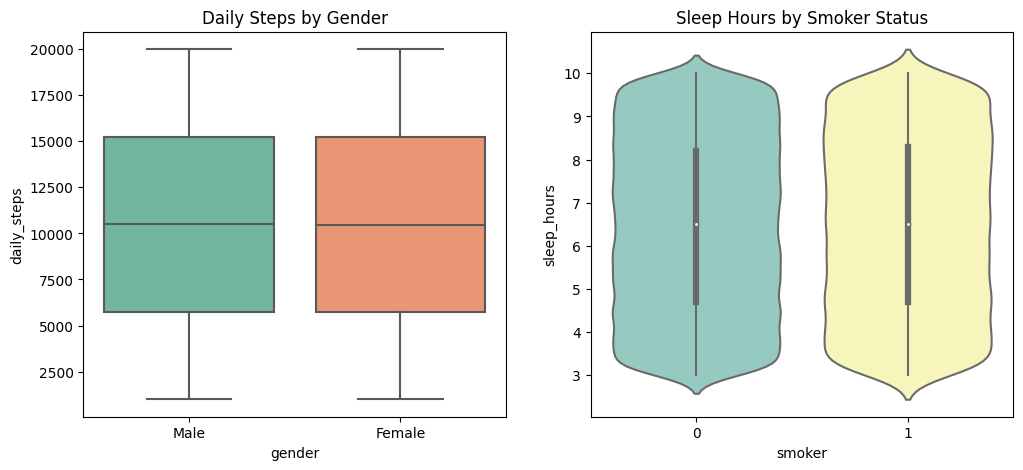

In [14]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x='gender', y='daily_steps', data=df, palette="Set2")
plt.title("Daily Steps by Gender")

plt.subplot(1,2,2)
sns.violinplot(x='smoker', y='sleep_hours', data=df, palette="Set3")
plt.title("Sleep Hours by Smoker Status")
plt.show()

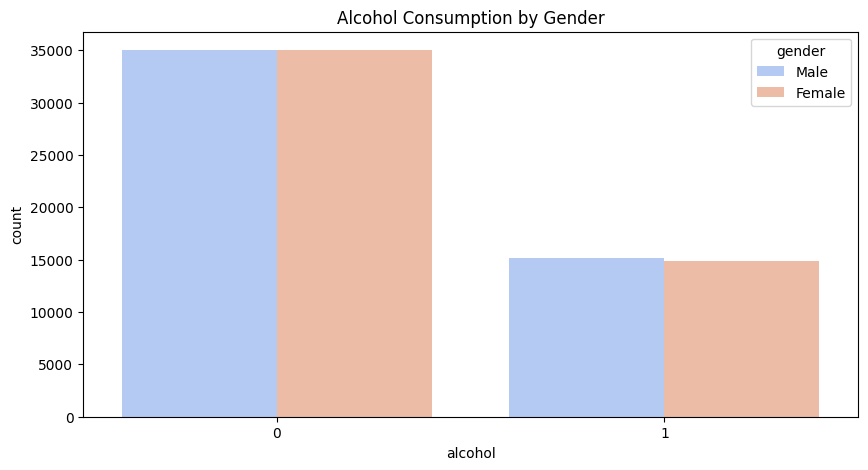

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(x='alcohol', hue='gender', data=df, palette="coolwarm")
plt.title("Alcohol Consumption by Gender")
plt.show()

Text(0.5, 1.0, 'Resting Heart Rate')

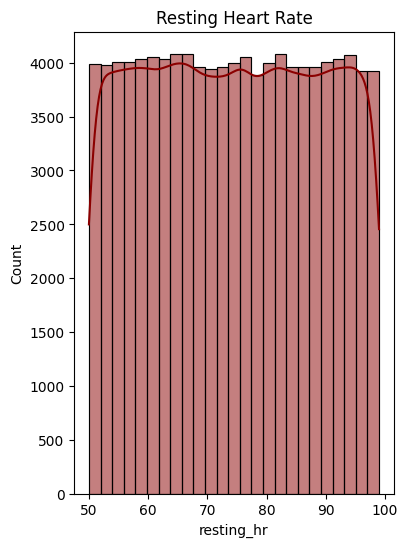

In [16]:
plt.figure(figsize=(14,6))
plt.subplot(1,3,1)
sns.histplot(df['resting_hr'], bins=25, kde=True, color="darkred")
plt.title("Resting Heart Rate")


Text(0.5, 1.0, 'Blood Pressure (Systolic vs Diastolic)')

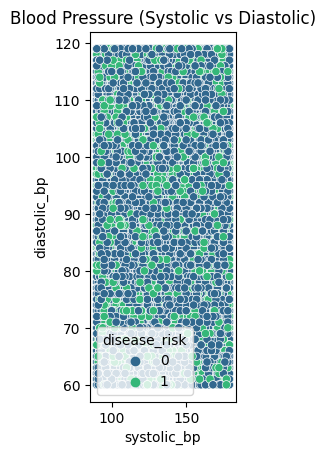

In [17]:
plt.subplot(1,3,2)
sns.scatterplot(x='systolic_bp', y='diastolic_bp', data=df, hue='disease_risk', palette="viridis")
plt.title("Blood Pressure (Systolic vs Diastolic)")


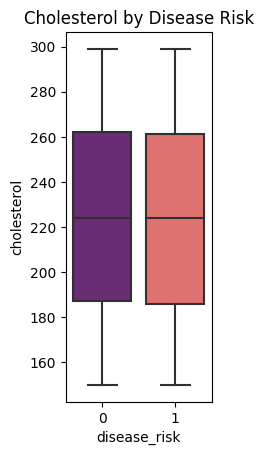

In [18]:
plt.subplot(1,3,3)
sns.boxplot(x='disease_risk', y='cholesterol', data=df, palette="magma")
plt.title("Cholesterol by Disease Risk")
plt.show()


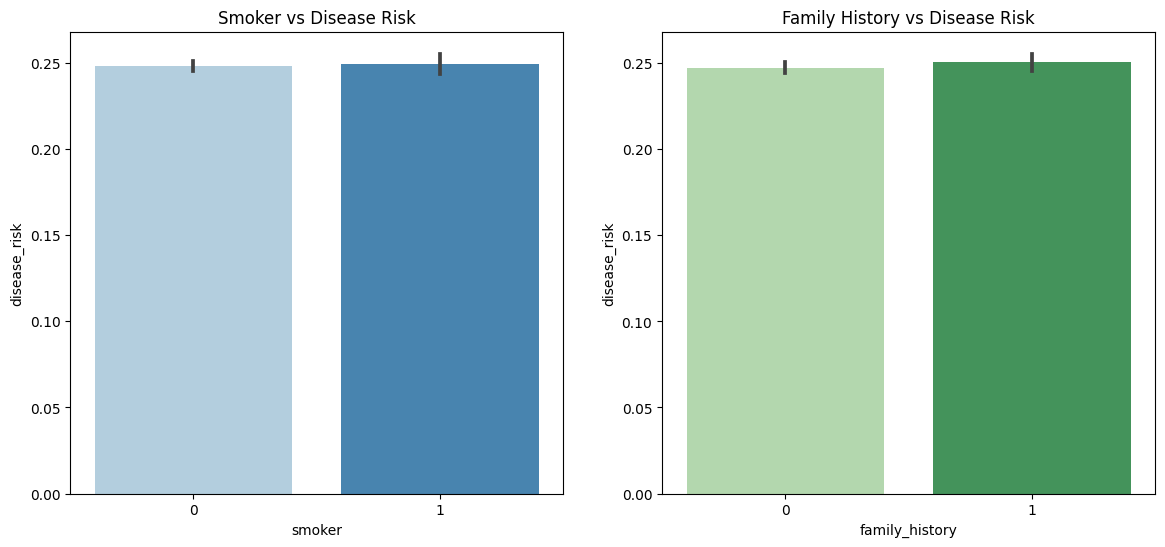

In [19]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.barplot(x='smoker', y='disease_risk', data=df, palette="Blues")
plt.title("Smoker vs Disease Risk")

plt.subplot(1,2,2)
sns.barplot(x='family_history', y='disease_risk', data=df, palette="Greens")
plt.title("Family History vs Disease Risk")
plt.show()

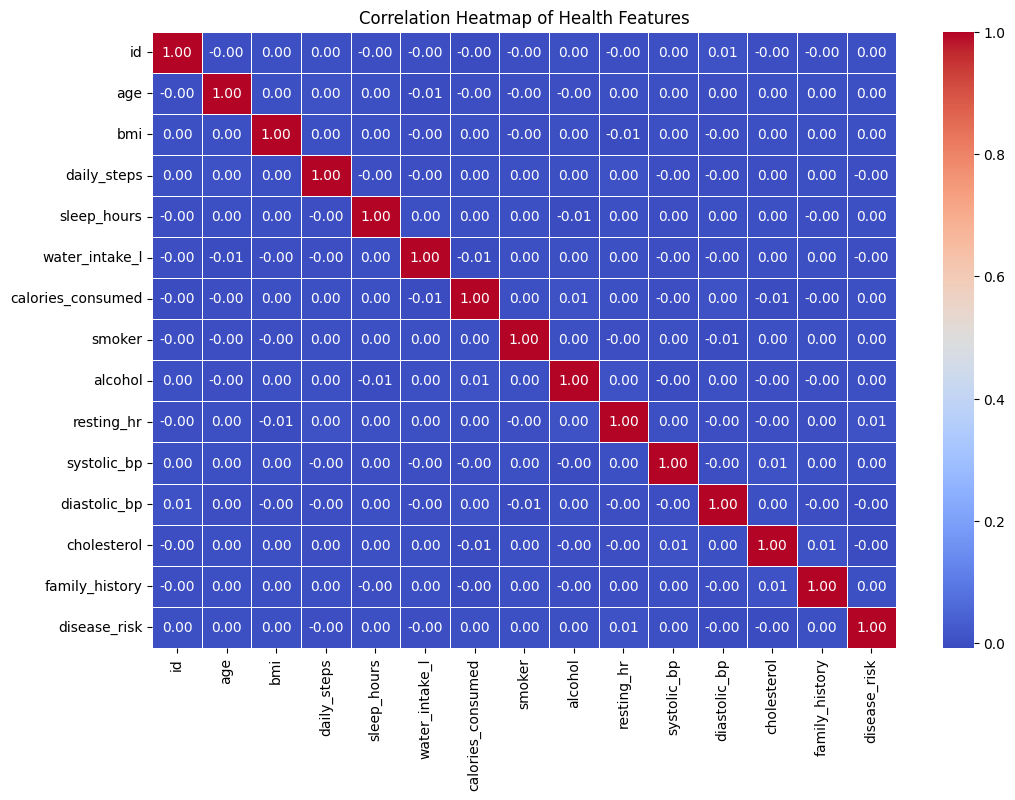

In [20]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Health Features")
plt.show()

## ML Algorithms

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [22]:
categorical_cols = ['gender', 'smoker', 'alcohol', 'family_history']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [23]:
X = df.drop(columns=['id', 'disease_risk'])
y = df['disease_risk']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "KNN": KNeighborsClassifier()
}


In [27]:
results = {}
for name, model in models.items():
    if name in ["Logistic Regression", "KNN"]:  # need scaling
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:  # trees don’t need scaling
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds) * 100
    results[name] = acc

In [28]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy (%)"])
print(results_df)

                 Model  Accuracy (%)
0  Logistic Regression        75.180
1        Decision Tree        61.695
2        Random Forest        75.175
3                  KNN        69.780


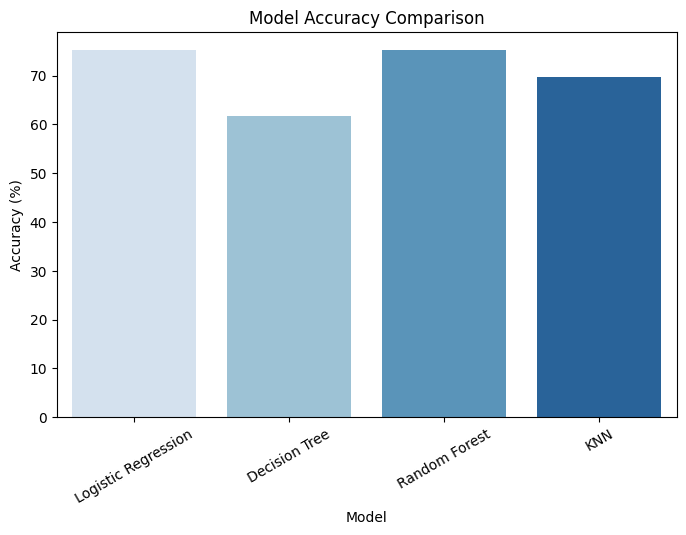

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy (%)", data=results_df, palette="Blues")
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.show()

## Thank you..pls upvote!!